In [11]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt
import pickle

In [2]:
# Define the basin states

bound_A = -0.8
bound_B = 0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

In [12]:
# Gap sweep, note that g = 2Vc, and Ea = e(1-Vc/e)

v_init = -0.0087
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000
temperature = 10000

x0 = 1.0
k = 0.1
eps = 0.05

Vc = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

max_traj_length = 5000
ensemble_size = 10000
tps_ensemble_list = []
naive_tps_ensemble_list = []
MC_rate_list = []
TT_dist_list = []
mtt_list = []
mtt_std_list = []
autocorr_list = []
mean_hop_list = []
mean_hop_std = []
q_hop_dist_list = []

for coupling in Vc:
    SHO_H = DoubleHarmonic(k=2 * eps, x0=1.0, vc=coupling * eps)
    C_init = SHO_H.eigvecs(q_init)
    initial_snapshot = Snapshot(positions=q_init,
                                velocities=v_init,
                                coefficients=coeff_init,
                                active_state=act_state_init,
                                gauge=C_init,
                                mass=mass,
                                is_grid=True)

    seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)
    seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)
    
    tps_selector = UniformShootingSelector(temp=temperature, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9)
    path_sampling = PathSampling(selector=tps_selector, seed_traj=seed_traj, max_iter=ensemble_size,
                                max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)
    engine_builder = MASHEngine
    tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)
    tps_ensemble_list.append(tps_ensemble)
    naive_tps_ensemble_list.append(naive_tps_ensemble)
    MC_rate = path_sampling.MC_acceptance()
    MC_rate_list.append(MC_rate)
    transit_times, mean_time, std_time = path_sampling.transit_time_statistics(tps_ensemble=tps_ensemble, dt=dt)
    TT_dist_list.append(transit_times)
    mtt_list.append(mean_time)
    mtt_std_list.append(std_time)

    max_lag = 100
    auto_correlation = path_sampling.compute_autocorrelation(data=transit_times, max_lag=max_lag)
    autocorr_list.append(auto_correlation)

    mean_hops, std_hops, q_hops = path_sampling.hop_statistics(tps_ensemble=tps_ensemble)
    mean_hop_list.append(mean_hops)
    mean_hop_std.append(std_hops)
    q_hop_dist_list.append(q_hops)

    grand_list_T = {'tps_ensemble': tps_ensemble, 'naive_ensemble': naive_tps_ensemble,
                    'MC rate': MC_rate, 'Transition time': transit_times,
                    'Autocorrelation': auto_correlation, 'hopping geometries': q_hops}
    
    with open(f"TPS_data_Vc{int(coupling*10)}.pkl", "wb") as f:
        pickle.dump(grand_list_T, f)


--- TPS Iteration 0 ---
Accepted
--- TPS Iteration 1 ---
Rejected
--- TPS Iteration 2 ---
Accepted
--- TPS Iteration 3 ---
Accepted
--- TPS Iteration 4 ---
Rejected
--- TPS Iteration 5 ---
Accepted
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Rejected
--- TPS Iteration 8 ---
Rejected
--- TPS Iteration 9 ---
Accepted
--- TPS Iteration 10 ---
Accepted
--- TPS Iteration 11 ---
Accepted
--- TPS Iteration 12 ---
Accepted
--- TPS Iteration 13 ---
Accepted
--- TPS Iteration 14 ---
Rejected
--- TPS Iteration 15 ---
Rejected
--- TPS Iteration 16 ---
Accepted
--- TPS Iteration 17 ---
Rejected
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Accepted
--- TPS Iteration 21 ---
Accepted
--- TPS Iteration 22 ---
Rejected
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Rejected
--- TPS Iteration 25 ---
Accepted
--- TPS Iteration 26 ---
Accepted
--- TPS Iteration 27 ---
Accepted
--- TPS Iteration 28 ---
Accepted
--- TPS Iteration 29 ---

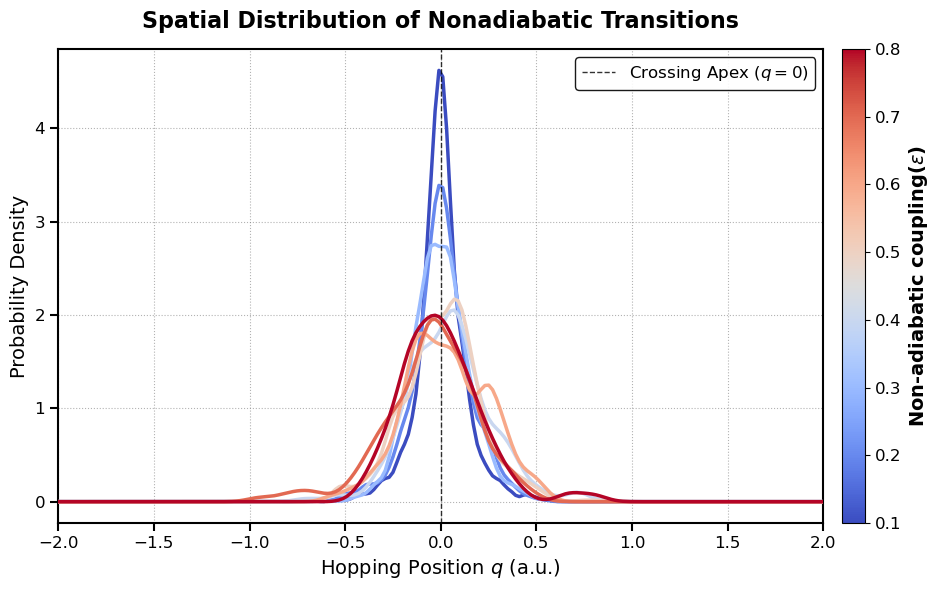

In [14]:
# Hopping geometry distribution
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_hopping_geometry_kde(temperature_sweep, q_hop_dist_list, min_hops=50):
    """
    Plots an overlaid KDE density map of the hopping geometries, 
    color-coded by temperature.
    """
    plt.figure(figsize=(10, 6))
    
    # Setup colormap (coolwarm naturally maps Cold=Blue, Hot=Red)
    norm = mcolors.Normalize(vmin=min(temperature_sweep), vmax=max(temperature_sweep))
    cmap = cm.coolwarm
    
    # Define the x-axis range for evaluating the KDE
    # You may need to adjust the bounds (-5 to 5) based on your specific potential
    q_eval = np.linspace(-5, 5, 500) 
    
    plotted_any = False
    
    for temp, q_hops in zip(temperature_sweep, q_hop_dist_list):
        q_hops = np.array(q_hops)
        
        # Strict statistical filtering: Skip if there are too few hops
        if len(q_hops) < min_hops:
            continue
            
        # Calculate the smooth Kernel Density Estimate
        try:
            # We use a slight bandwidth adjustment to keep the curves smooth but accurate
            kde = gaussian_kde(q_hops, bw_method='scott') 
            density = kde(q_eval)
        except np.linalg.LinAlgError:
            # Failsafe: skips if all hops happen at the exact same float value (zero variance)
            continue
            
        color = cmap(norm(temp))
        
        # Plot the density line and fill underneath for a modern, beautiful aesthetic
        plt.plot(q_eval, density, color=color, linewidth=2.5, zorder=3)
        # plt.fill_between(q_eval, density, color=color, alpha=0.1, zorder=2)
        
        plotted_any = True
        
    if not plotted_any:
        print("Error: No ensembles met the min_hops criteria.")
        return
        
    # Add a continuous colorbar to act as the legend for Temperature
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02)
    cbar.set_label(r'Non-adiabatic coupling($\epsilon$)', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    
    # Mark the theoretical avoided crossing center (usually q=0)
    plt.axvline(x=0, color='black', linestyle='--', linewidth=1, alpha=0.8, 
                zorder=4, label='Crossing Apex ($q=0$)')
    
    # Aesthetics
    plt.title("Spatial Distribution of Nonadiabatic Transitions", fontsize=16, fontweight='bold', pad=15)
    plt.xlabel("Hopping Position $q$ (a.u.)", fontsize=14, fontweight='medium')
    plt.ylabel("Probability Density", fontsize=14, fontweight='medium')
    plt.xlim([-2,2])
    
    plt.grid(True, linestyle=':', alpha=0.6, color='gray', zorder=1)
    
    ax = plt.gca()
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
    ax.tick_params(width=1.5, length=6, labelsize=12)
    
    plt.legend(loc='upper right', fontsize=12, framealpha=0.9, edgecolor='black')
    
    plt.tight_layout()
    plt.show()

# Run it:
# (Note: adjust the q_eval linspace bounds inside the function if your q limits are wider than -5 to 5)
plot_hopping_geometry_kde(Vc, q_hop_dist_list)

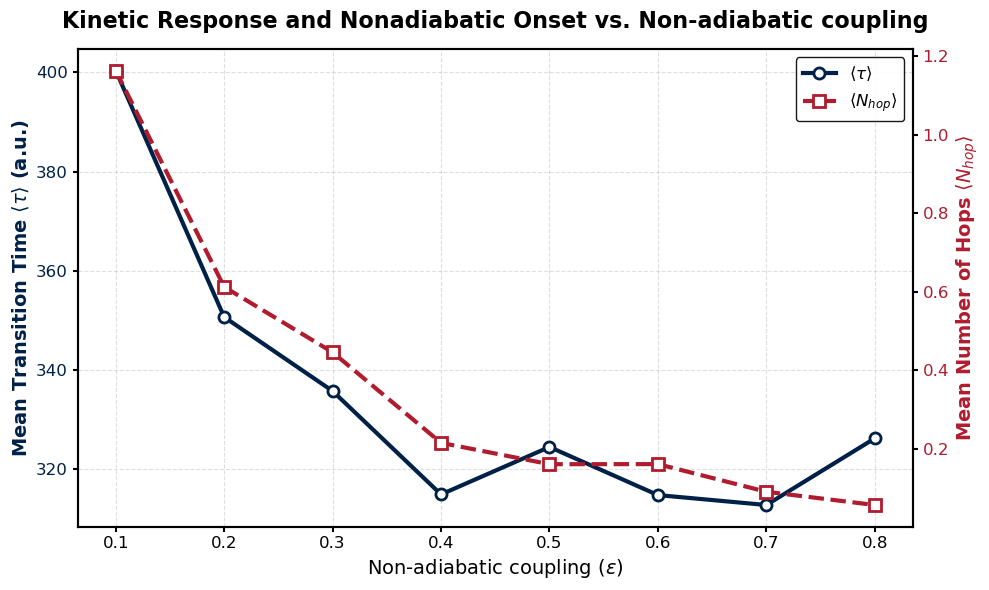

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_kinetics_vs_mechanism(temperature_sweep, mtt_list, mean_hop_list):
    """
    Plots an overlay of Mean Transition Time and Mean Number of Hops 
    sharing the Temperature x-axis.
    """
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Professional color palette
    color_time = '#002147'  # Oxford Blue for Transition Time
    color_hops = '#b01c2e'  # Deep Red for Hops

    # ==========================================
    # LEFT AXIS: Mean Transition Time
    # ==========================================
    ax1.set_xlabel(r'Non-adiabatic coupling ($\epsilon$)', fontsize=14, fontweight='medium')
    ax1.set_ylabel(r'Mean Transition Time $\langle \tau \rangle$ (a.u.)', color=color_time, fontsize=14, fontweight='bold')
    
    # Plotting the line and markers
    line1 = ax1.plot(temperature_sweep, mtt_list, color=color_time, linewidth=3, 
                     linestyle='-', marker='o', markersize=8, markerfacecolor='white', 
                     markeredgewidth=2, label=r'$\langle \tau \rangle$')
    
    # Color-code the ticks to match the line
    ax1.tick_params(axis='y', labelcolor=color_time, labelsize=12, width=1.5)
    ax1.tick_params(axis='x', labelsize=12, width=1.5)
    
    # Clean grid aligned with the primary axis
    ax1.grid(True, linestyle='--', alpha=0.4)

    # ==========================================
    # RIGHT AXIS: Mean Number of Hops
    # ==========================================
    ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
    ax2.set_ylabel(r'Mean Number of Hops $\langle N_{hop} \rangle$', color=color_hops, fontsize=14, fontweight='bold')
    
    # Plotting the secondary line and markers
    line2 = ax2.plot(temperature_sweep, mean_hop_list, color=color_hops, linewidth=3, 
                     linestyle='--', marker='s', markersize=8, markerfacecolor='white', 
                     markeredgewidth=2, label=r'$\langle N_{hop} \rangle$')
    
    # Color-code the ticks to match the line
    ax2.tick_params(axis='y', labelcolor=color_hops, labelsize=12, width=1.5)

    # ==========================================
    # AESTHETICS & LEGEND
    # ==========================================
    plt.title("Kinetic Response and Nonadiabatic Onset vs. Non-adiabatic coupling", fontsize=16, fontweight='bold', pad=15)
    
    # Thicken the bounding box for a print-ready look
    for ax in [ax1, ax2]:
        for spine in ax.spines.values():
            spine.set_linewidth(1.5)

    # Combine legends from both axes into one box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper right', fontsize=12, framealpha=0.9, edgecolor='black')

    fig.tight_layout()
    plt.show()

# Run the plot:
plot_kinetics_vs_mechanism(Vc, mtt_list, mean_hop_list)

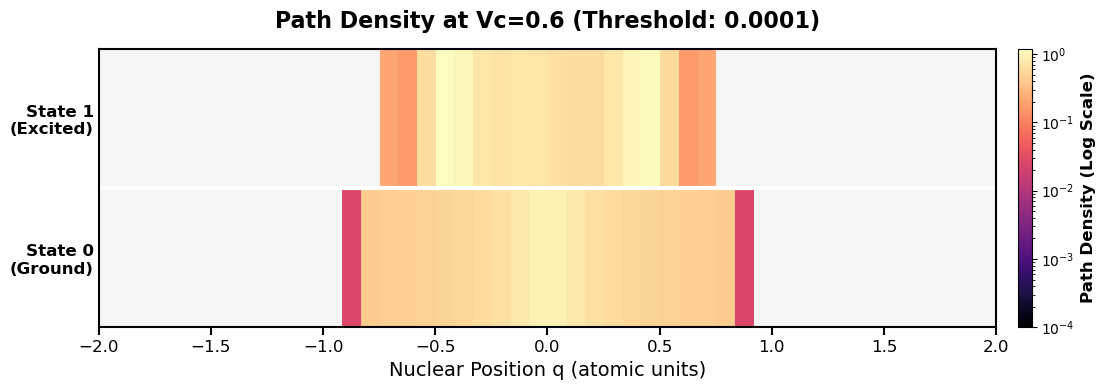

In [30]:
# Path density

PD_ensemble_list = [ensemble[1500:] for ensemble in tps_ensemble_list]

state1_pos = [[snap.positions for traj in ensemble for snap in traj if snap.active_state == 1] for ensemble in PD_ensemble_list]
state0_pos = [[snap.positions for traj in ensemble for snap in traj if snap.active_state == 0] for ensemble in PD_ensemble_list]

import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import copy

def plot_pruned_state_ribbons(pos_state0, pos_state1, num_bins=60, density_threshold=1e-3):
    """
    Plots discretized heatmaps bounded between -2.5 and 2.5, explicitly pruning 
    (hiding) any spatial bins where the density falls below the density_threshold.
    """
    # 1. Define the strictly bounded spatial grid
    grid_bins = np.linspace(-2.5, 2.5, num_bins + 1)
    
    # 2. Calculate the 1D density for each state
    density0, _ = np.histogram(pos_state0, bins=grid_bins, density=True)
    density1, _ = np.histogram(pos_state1, bins=grid_bins, density=True)
    
    # 3. Stack them into a 2xN matrix
    heatmap_matrix = np.vstack([density0, density1])
    
    # 4. THE PRUNING STEP: Mask out low-density bins with np.nan
    # This mathematically erases any bin that falls below your cutoff
    heatmap_matrix = np.where(heatmap_matrix < density_threshold, np.nan, heatmap_matrix)
    
    # ==========================================
    # PLOTTING THE PRUNED RIBBONS
    # ==========================================
    fig, ax = plt.subplots(figsize=(12, 4))
    
    # Copy the colormap so we can safely modify its "bad" (NaN) value behavior
    cmap = copy.copy(plt.cm.magma)
    cmap.set_bad(color='whitesmoke') # Renders pruned bins as a faint gray background
    
    # LogNorm scaling (safely ignoring NaNs when calculating the max)
    # The minimum value of the colorbar is now strictly your threshold!
    max_val = np.nanmax(heatmap_matrix)
    max_val = max_val if not np.isnan(max_val) and max_val > density_threshold else density_threshold * 10
    
    norm = mcolors.LogNorm(vmin=density_threshold, vmax=max_val)
    
    # Render the discrete blocks
    cax = ax.imshow(heatmap_matrix, aspect='auto', origin='lower', 
                    cmap=cmap, norm=norm, interpolation='nearest',
                    extent=[-2.5, 2.5, -0.5, 1.5])
    
    # 5. Aesthetics and Labels
    ax.set_yticks([0, 1])
    ax.set_yticklabels(['State 0\n(Ground)', 'State 1\n(Excited)'], fontsize=12, fontweight='bold')
    
    ax.set_xlabel('Nuclear Position q (atomic units)', fontsize=14, fontweight='medium')
    ax.set_title(f'Path Density at Vc=0.6 (Threshold: {density_threshold})', fontsize=16, fontweight='bold', pad=15)
    
    # Add a clean horizontal line exactly between the two states
    ax.axhline(0.5, color='white', linewidth=3, linestyle='-')
    
    # Thicken axes
    for spine in ['top', 'right', 'bottom', 'left']:
        ax.spines[spine].set_linewidth(1.5)
    ax.tick_params(axis='x', width=1.5, length=6, labelsize=12)
    ax.tick_params(axis='y', length=0) 
    
    # Add Colorbar
    cbar = fig.colorbar(cax, ax=ax, pad=0.02)
    cbar.set_label('Path Density (Log Scale)', fontsize=12, fontweight='bold')
    
    # Enforce strict x-axis bounds
    ax.set_xlim(-2.0, 2.0)
    
    plt.tight_layout()
    plt.show()

# Run it and adjust the threshold to carve away the exact amount of noise you want:
# 

hot_state0 = state0_pos[5]
hot_state1 = state1_pos[5]

plot_pruned_state_ribbons(hot_state0, hot_state1, num_bins=60, density_threshold=1e-4)

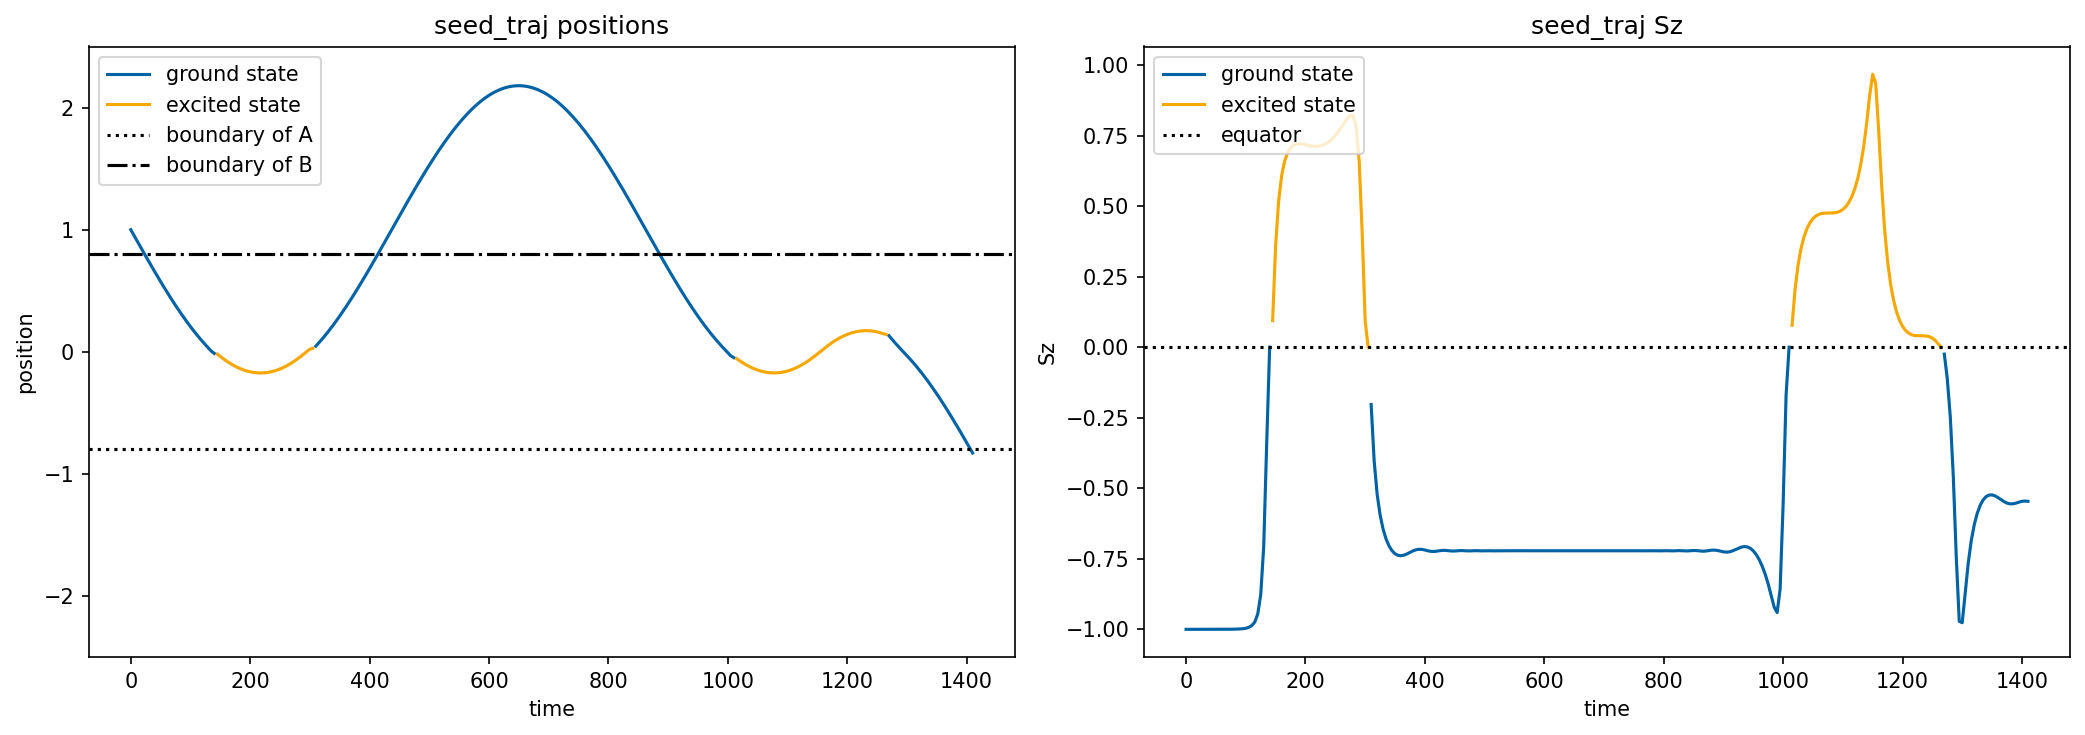

In [10]:
# PLOT SEED TRAJECTORY

labelstates = ["ground state", "excited state"]
colorstates = ["#0063A6","#F6A800","#666666"]

# --- Positions ---
oscillator_positions = np.array([seed_traj[i].positions for i in range(len(seed_traj))])
active_states = np.array([seed_traj[i].active_state for i in range(len(seed_traj))])
ground_state_positions = np.copy(oscillator_positions)
ground_state_positions[active_states > 0] = np.nan
excited_state_positions = np.copy(oscillator_positions)
excited_state_positions[active_states != 1] = np.nan

# --- Coefficients ---
oscillator_coeffs = np.array([sz_from_coeff(seed_traj[i].coefficients) for i in range(len(seed_traj))])
ground_state_coeffs = np.copy(oscillator_coeffs)
ground_state_coeffs[active_states > 0] = np.nan
excited_state_coeffs = np.copy(oscillator_coeffs)
excited_state_coeffs[active_states != 1] = np.nan

# --- Create subplots ---
fig, axes = plt.subplots(ncols=2, figsize=(14, 5), dpi=150)

# Left: Positions
axes[0].plot(np.arange(len(seed_traj)) * dt, ground_state_positions, color=colorstates[0], label="ground state")
axes[0].plot(np.arange(len(seed_traj)) * dt, excited_state_positions, color=colorstates[1], label="excited state")
axes[0].axhline(y=bound_A, linestyle=":", color='black', label="boundary of A")
axes[0].axhline(y=bound_B, linestyle="-.", color='black', label="boundary of B")
axes[0].set_xlabel("time")
axes[0].set_ylabel("position")
axes[0].set_ylim([-2.5, 2.5])
axes[0].set_title("seed_traj positions")
axes[0].legend(loc=2)

# Right: Sz
axes[1].plot(np.arange(len(seed_traj)) * dt, ground_state_coeffs, color=colorstates[0], label="ground state")
axes[1].plot(np.arange(len(seed_traj)) * dt, excited_state_coeffs, color=colorstates[1], label="excited state")
axes[1].axhline(y=0, linestyle=":", color='black', label="equator")
axes[1].set_xlabel("time")
axes[1].set_ylabel("Sz")
axes[1].set_title("seed_traj Sz")
axes[1].legend(loc=2)

plt.tight_layout()
plt.show()